### Import Libraries

In [2]:
# import libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

In [5]:
# Scikit-learn imports
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, classification_report, confusion_matrix,
                            roc_curve, auc, precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize
import os

### Download NLTK Data

In [7]:
# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### LOAD DATASETS

In [9]:
# Load train and test datasets
train_df = pd.read_json("train_dataset.jsonl", lines=True)
test_df = pd.read_json("test_dataset.jsonl", lines=True)

In [10]:
print("DATASET LOADED SUCCESSFULLY")
print(f"Training set: {train_df.shape[0]} samples, {train_df.shape[1]} columns")
print(f"Test set: {test_df.shape[0]} samples, {test_df.shape[1]} columns")

DATASET LOADED SUCCESSFULLY
Training set: 120000 samples, 3 columns
Test set: 7600 samples, 3 columns


In [11]:
train_df 


,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
...,...,...,...
119995,1,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...
119996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...
119997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...
119998,2,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...


In [12]:
test_df

,label,title,description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...
...,...,...,...
7595,1,Around the world,Ukrainian presidential candidate Viktor Yushch...
7596,2,Void is filled with Clement,With the supply of attractive pitching options...
7597,2,Martinez leaves bitter,Like Roger Clemens did almost exactly eight ye...
7598,3,5 of arthritis patients in Singapore take Bext...,SINGAPORE : Doctors in the United States have ...


### CLASS NAME INFORMATION

1: World
2: Sports 
3: Business
4: Sci/Tech

### BASIC DATA EXPLORATION

In [15]:
print("DATASET INFORMATION")
print("\nTraining Data Info:")
train_df.info()

DATASET INFORMATION

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   label        120000 non-null  int64 
 1   title        120000 non-null  object
 2   description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [16]:
print("STATISTICAL SUMMARY")
train_df.describe()

STATISTICAL SUMMARY


,label
count,120000.000000
mean,2.500000
std,1.118039
min,1.000000
25%,1.750000
50%,2.500000
75%,3.250000
max,4.000000


In [17]:
# Check for missing values
print("MISSING VALUES CHECK")
print("\nTraining set missing values:")
print(train_df.isnull().sum())
print("\nTest set missing values:")
print(test_df.isnull().sum())

MISSING VALUES CHECK

Training set missing values:
label          0
title          0
description    0
dtype: int64

Test set missing values:
label          0
title          0
description    0
dtype: int64


In [18]:
# Class distribution
print("CLASS DISTRIBUTION")
print("\nTraining set:")
print(train_df['label'].value_counts())
print("\nTest set:")
print(test_df['label'].value_counts())

CLASS DISTRIBUTION

Training set:
label
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64

Test set:
label
3    1900
4    1900
2    1900
1    1900
Name: count, dtype: int64


### VISUALIZATION 1 - CLASS DISTRIBUTION PIE CHARTS

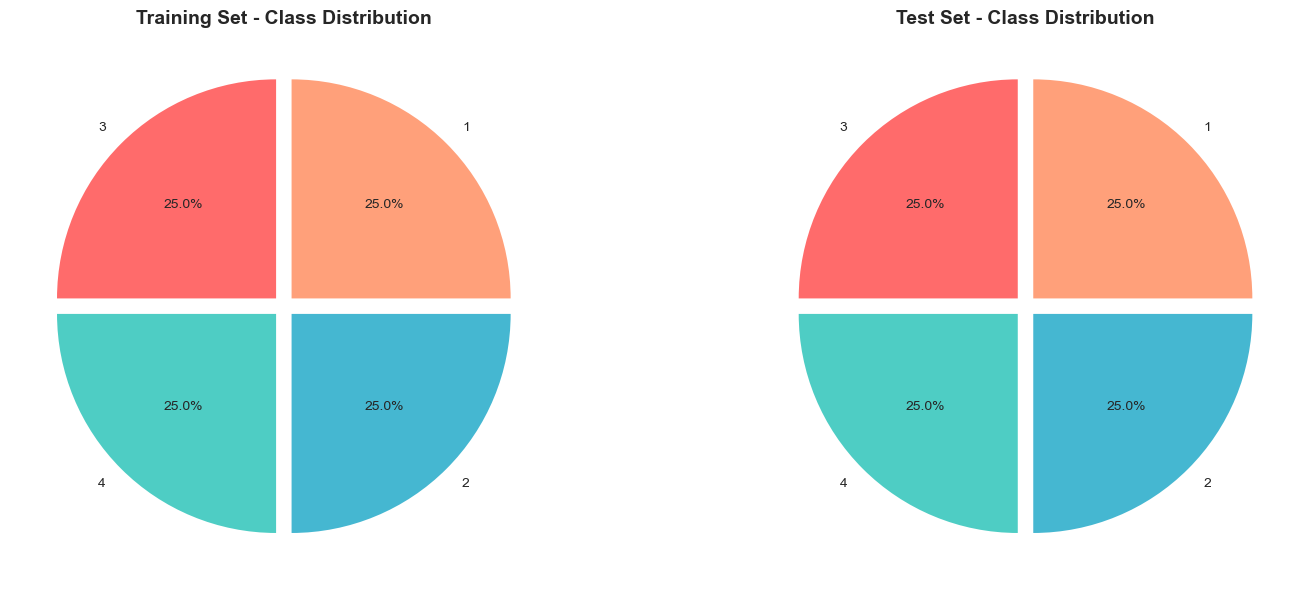

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

# Training data pie chart
class_counts_train = train_df['label'].value_counts()
axes[0].pie(class_counts_train.values, labels=class_counts_train.index, 
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=[0.05]*len(class_counts_train))
axes[0].set_title('Training Set - Class Distribution', fontsize=14, fontweight='bold')

# Test data pie chart
class_counts_test = test_df['label'].value_counts()
axes[1].pie(class_counts_test.values, labels=class_counts_test.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=[0.05]*len(class_counts_test))
axes[1].set_title('Test Set - Class Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### VISUALIZATION 2 - CLASS DISTRIBUTION BAR CHART

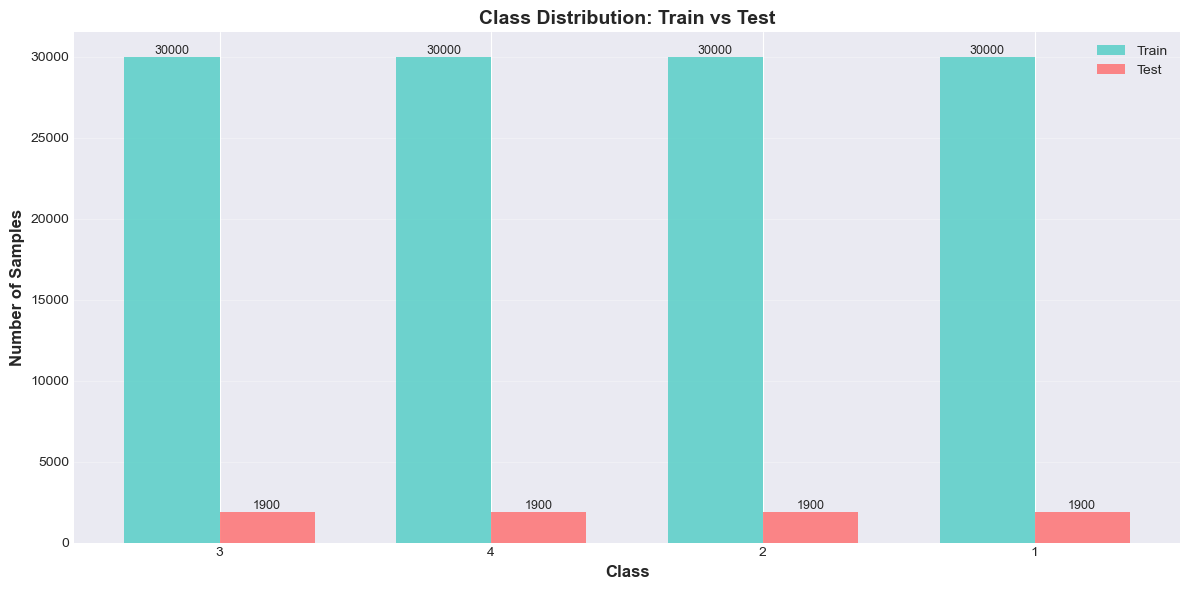

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(class_counts_train))
width = 0.35

bars1 = ax.bar(x - width/2, class_counts_train.values, width, 
               label='Train', color='#4ECDC4', alpha=0.8)
bars2 = ax.bar(x + width/2, class_counts_test.values, width,
               label='Test', color='#FF6B6B', alpha=0.8)

ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('Class Distribution: Train vs Test', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_counts_train.index)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#### CREATE FULL TEXT AND CALCULATE TEXT STATISTICS

In [24]:
# Combine title and description
train_df['full_text'] = train_df['title'] + ' ' + train_df['description']
test_df['full_text'] = test_df['title'] + ' ' + test_df['description']
# Calculate text statistics
train_df['text_length'] = train_df['full_text'].str.len()
train_df['word_count'] = train_df['full_text'].str.split().str.len()

test_df['text_length'] = test_df['full_text'].str.len()
test_df['word_count'] = test_df['full_text'].str.split().str.len()

In [25]:
print("TEXT STATISTICS:")
print(f"\nAverage text length: {train_df['text_length'].mean():.2f} characters")
print(f"Average word count: {train_df['word_count'].mean():.2f} words")
print(f"Max text length: {train_df['text_length'].max()} characters")
print(f"Min text length: {train_df['text_length'].min()} characters")

TEXT STATISTICS:

Average text length: 236.48 characters
Average word count: 37.85 words
Max text length: 1012 characters
Min text length: 100 characters


### VISUALIZATION 3 - TEXT LENGTH BOX PLOTS

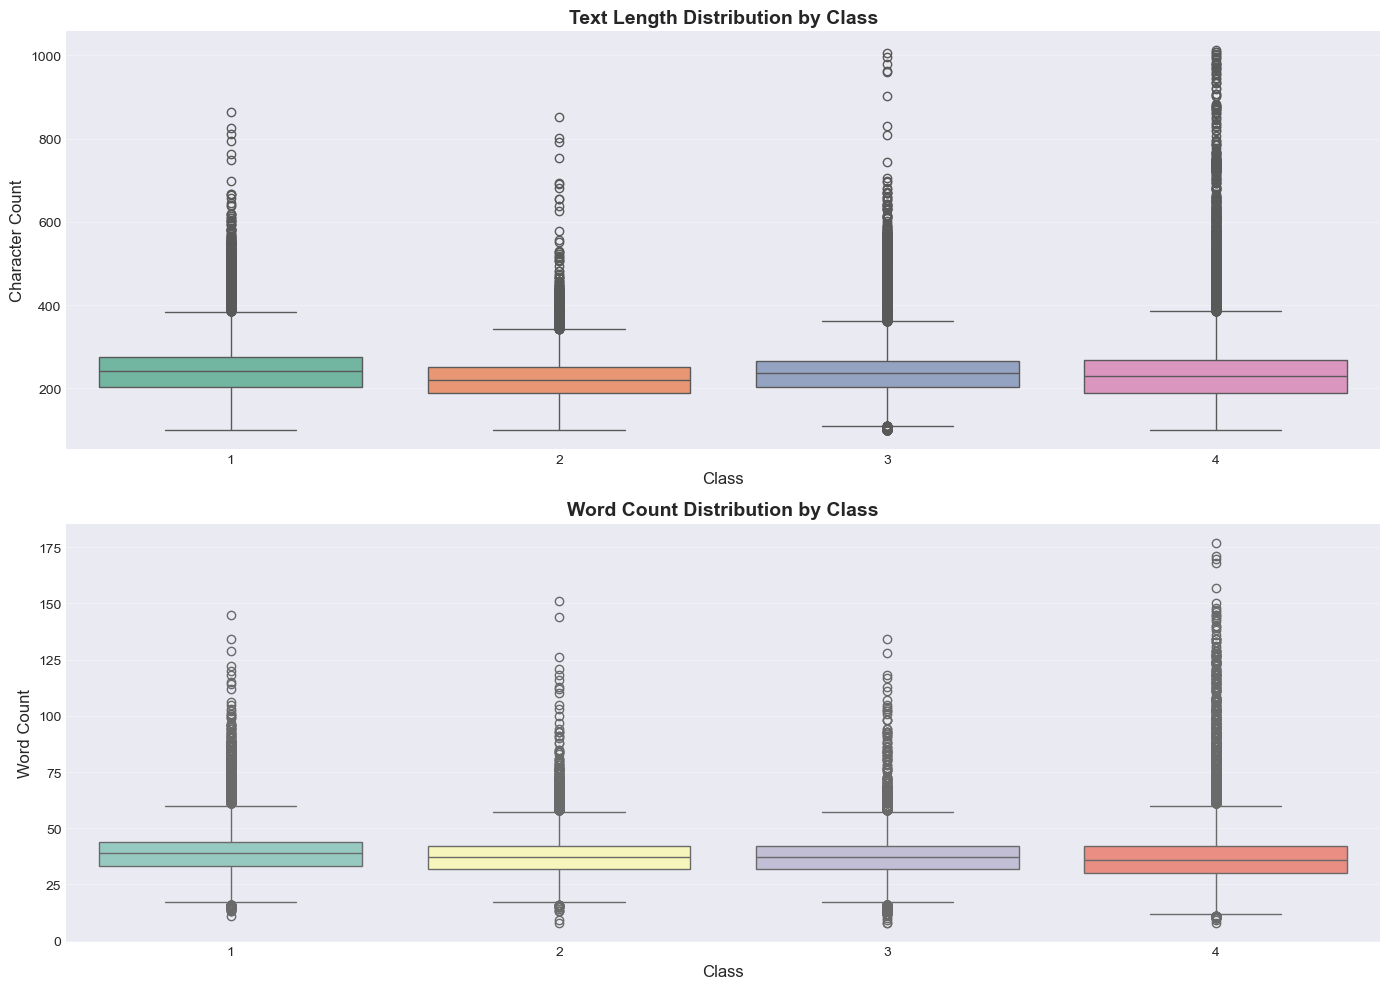

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Character length box plot
sns.boxplot(data=train_df, x='label', y='text_length', ax=axes[0], palette='Set2')
axes[0].set_title('Text Length Distribution by Class', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Character Count', fontsize=12)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Word count box plot
sns.boxplot(data=train_df, x='label', y='word_count', ax=axes[1], palette='Set3')
axes[1].set_title('Word Count Distribution by Class', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Word Count', fontsize=12)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### VISUALIZATION 4 - DISTRIBUTION HISTOGRAMS

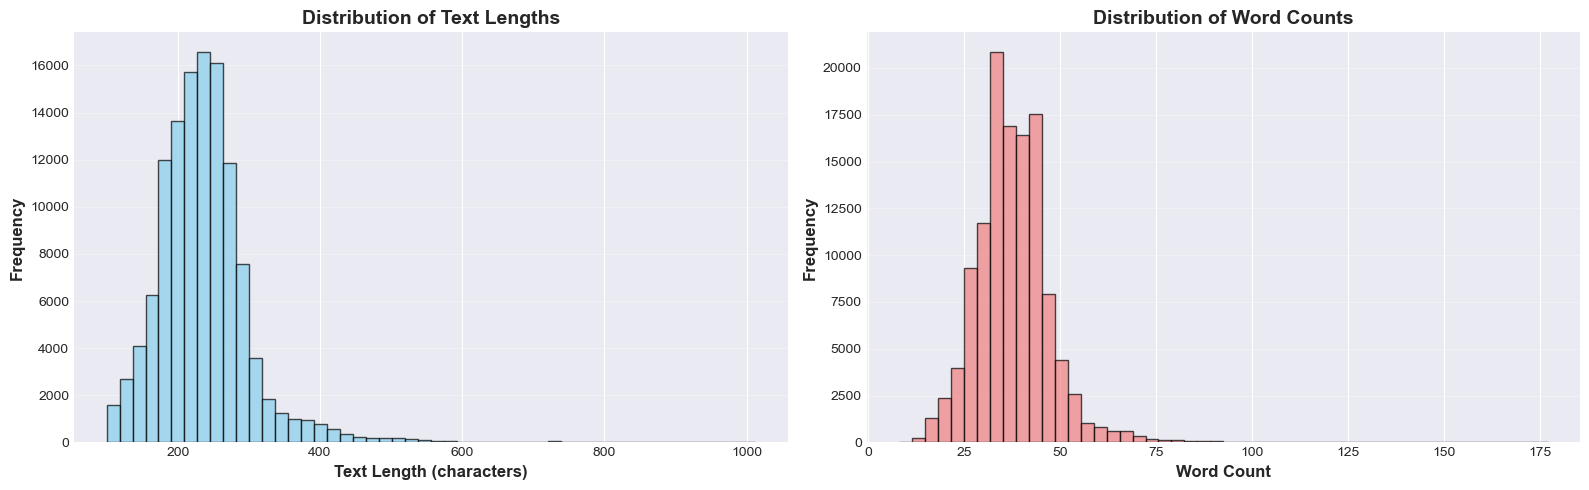

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Text length histogram
axes[0].hist(train_df['text_length'], bins=50, color='skyblue', 
             edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Text Length (characters)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of Text Lengths', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Word count histogram
axes[1].hist(train_df['word_count'], bins=50, color='lightcoral', 
             edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Word Count', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Distribution of Word Counts', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### VISUALIZATION 5 - WORD CLOUDS BY CLASS

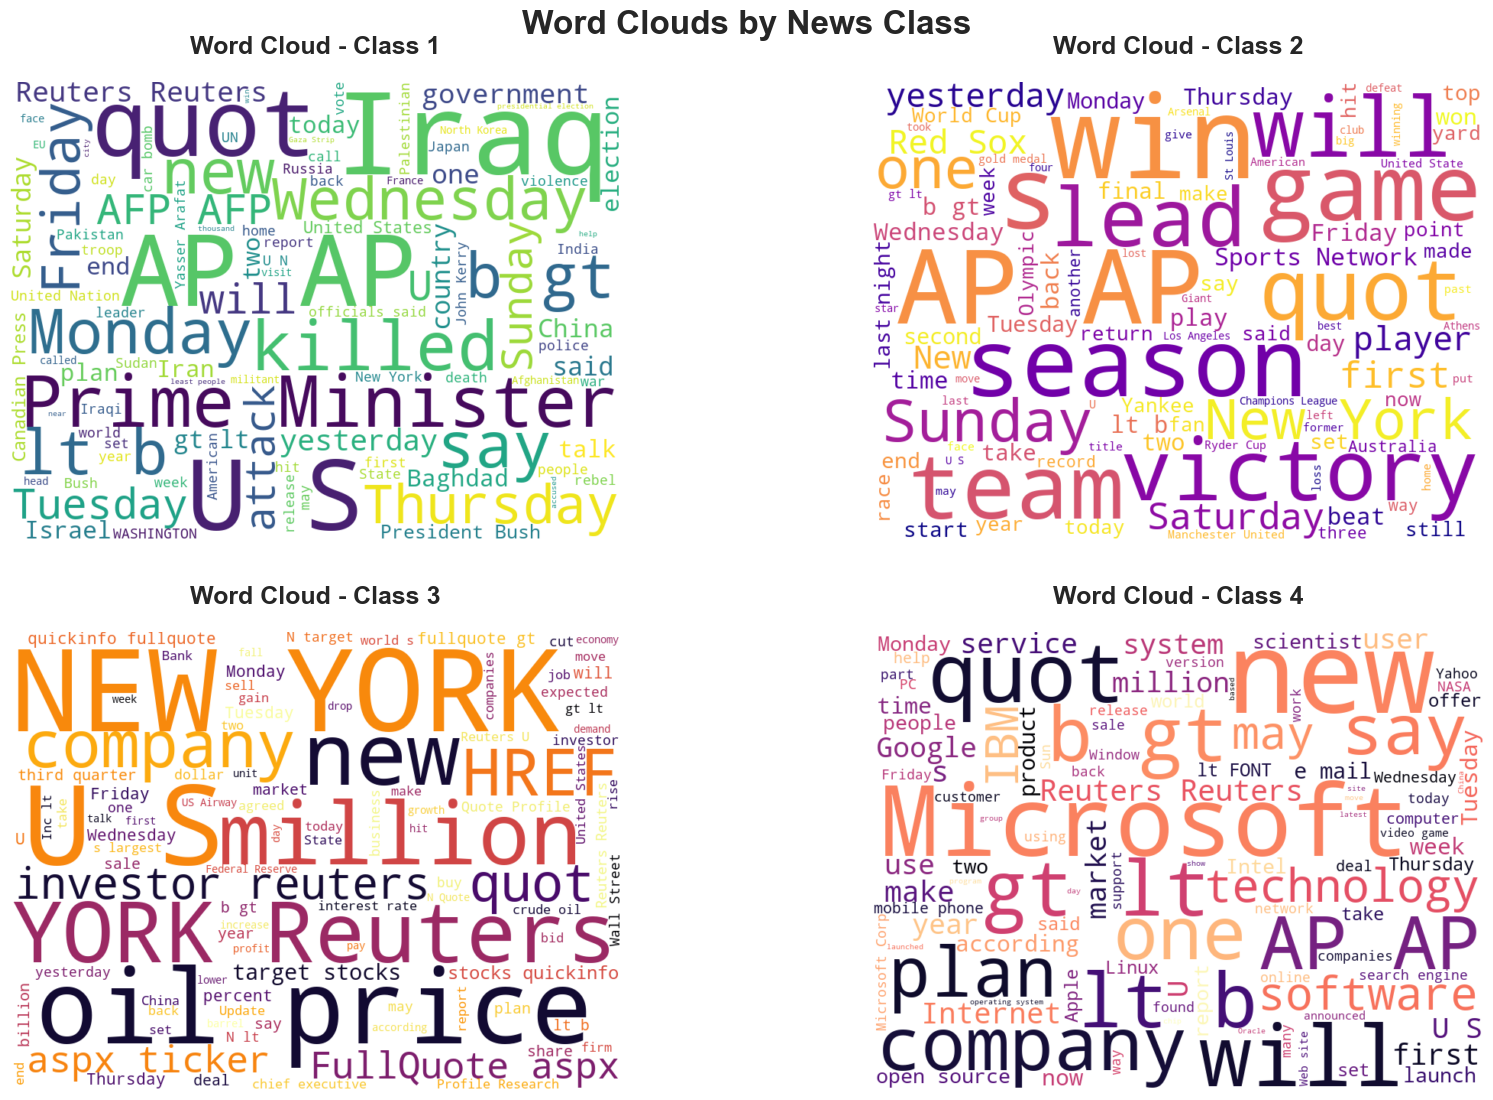

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12)) 
axes = axes.ravel()
unique_labels = sorted(train_df['label'].unique())
colormaps = ['viridis', 'plasma', 'inferno', 'magma']  
for idx, label in enumerate(unique_labels):
    text = ' '.join(train_df[train_df['label'] == label]['full_text'].astype(str).values)
    wordcloud = WordCloud(
        width=800,
        height=600,                    
        background_color='white',
        colormap=colormaps[idx],       
        max_words=100,
        min_font_size=10,
        max_font_size=150,
        relative_scaling=0.5,
        random_state=42               
    ).generate(text)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud - Class {label}', fontsize=18, fontweight='bold', pad=20) 
    axes[idx].axis('off')

plt.subplots_adjust(
    left=0.05,
    right=0.95,
    top=0.92,
    bottom=0.08,
    wspace=0.14,  
    hspace=0.20    
)
plt.suptitle('Word Clouds by News Class', fontsize=24, fontweight='bold', y=0.98)
plt.show()

### TEXT STATISTICS BY CLASS

In [33]:
stats_by_class = train_df.groupby('label').agg({
    'text_length': ['mean', 'median', 'std', 'min', 'max'],
    'word_count': ['mean', 'median', 'std', 'min', 'max']
}).round(2)

print("TEXT STATISTICS BY CLASS")
print(stats_by_class)

TEXT STATISTICS BY CLASS
      text_length                          word_count                       
             mean median    std  min   max       mean median    std min  max
label                                                                       
1          242.63  243.0  63.63  100   865      38.88   39.0  10.32  11  145
2          224.65  220.0  50.50  100   853      37.77   37.0   8.87   8  151
3          241.41  236.0  64.26  100  1006      37.54   37.0   8.12   8  134
4          237.22  230.0  82.24  100  1012      37.19   36.0  12.42   8  177


### TEXT PREPROCESSING CLASS

In [35]:
class TextPreprocessor:
    """Complete text preprocessing pipeline"""
    
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))
    
    def clean_text(self, text):
        """Clean text: lowercase, remove special chars, extra spaces"""
        if pd.isna(text):
            return ""
        
        # Convert to lowercase
        text = text.lower()
        
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        
        # Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)
        
        # Remove special characters and digits
        text = re.sub(r'[^a-zA-Z\s]', ' ', text)
        
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    
    def tokenize(self, text):
        """Tokenize text into words"""
        return word_tokenize(text)
    
    def remove_stopwords(self, tokens):
        """Remove stopwords from token list"""
        return [word for word in tokens if word not in self.stop_words]
    
    def lemmatize(self, tokens):
        """Lemmatize tokens"""
        return [self.lemmatizer.lemmatize(word) for word in tokens]
    
    def preprocess(self, text):
        """Complete preprocessing pipeline"""
        # Clean text
        text = self.clean_text(text)
        
        # Tokenize
        tokens = self.tokenize(text)
        
        # Remove stopwords
        tokens = self.remove_stopwords(tokens)
        
        # Lemmatize
        tokens = self.lemmatize(tokens)
        
        # Join tokens back to string
        return ' '.join(tokens)

print("TextPreprocessor class defined successfully!")

TextPreprocessor class defined successfully!


### APPLY PREPROCESSING

In [37]:
# Initialize preprocessor
preprocessor = TextPreprocessor()

print("Preprocessing training data...")
train_df['processed_text'] = train_df['full_text'].apply(preprocessor.preprocess)

print("Preprocessing test data...")
test_df['processed_text'] = test_df['full_text'].apply(preprocessor.preprocess)

Preprocessing training data...
Preprocessing test data...


In [38]:
# Handle missing values
train_df['processed_text'].fillna('', inplace=True)
test_df['processed_text'].fillna('', inplace=True)

print("\n Text preprocessing complete!")


 Text preprocessing complete!


In [39]:
# Preprocessing text
print("PREPROCESSING TEXT")
for i in range(3):
    print(f"\n--- Sample {i+1} ---")
    print(f"Original: {train_df['full_text'].iloc[i][:150]}...")
    print(f"Processed: {train_df['processed_text'].iloc[i][:150]}...")

PREPROCESSING TEXT

--- Sample 1 ---
Original: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again....
Processed: wall st bear claw back black reuters reuters short seller wall street dwindling band ultra cynic seeing green...

--- Sample 2 ---
Original: Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and ...
Processed: carlyle look toward commercial aerospace reuters reuters private investment firm carlyle group reputation making well timed occasionally controversial...

--- Sample 3 ---
Original: Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expecte...
Processed: oil economy cloud stock outlook reuters reuters soaring crude price plus worry economy outlook earnings expected hang stock market next week 

In [40]:
# Statistics
print("PREPROCESSING STATISTICS")
orig_avg = train_df['full_text'].str.len().mean()
proc_avg = train_df['processed_text'].str.len().mean()
reduction = (1 - proc_avg / orig_avg) * 100

print(f"Original average length: {orig_avg:.2f} characters")
print(f"Processed average length: {proc_avg:.2f} characters")
print(f"Reduction: {reduction:.2f}%")

PREPROCESSING STATISTICS
Original average length: 236.48 characters
Processed average length: 175.87 characters
Reduction: 25.63%


### TF-IDF FEATURE EXTRACTION

In [42]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,      
    min_df=2,               
    max_df=0.8,             
    ngram_range=(1, 2),    
    sublinear_tf=True       
)

In [43]:
# Fit and transform training data
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['processed_text'])
y_train = train_df['label']

In [44]:
# Transform test data
X_test_tfidf = tfidf_vectorizer.transform(test_df['processed_text'])
y_test = test_df['label']

print(f"\n TF-IDF features created!")
print(f"Training set shape: {X_train_tfidf.shape}")
print(f"Test set shape: {X_test_tfidf.shape}")
print(f"Number of features: {len(tfidf_vectorizer.get_feature_names_out())}")
print(f"Sparsity: {(1.0 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100:.2f}%")


 TF-IDF features created!
Training set shape: (120000, 5000)
Test set shape: (7600, 5000)
Number of features: 5000
Sparsity: 99.60%


### VISUALIZATION 6 - TOP TF-IDF FEATURES

In [46]:
# Get feature names and scores
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_scores = X_train_tfidf.sum(axis=0).A1
top_indices = tfidf_scores.argsort()[-20:][::-1]
top_features = [(feature_names[i], tfidf_scores[i]) for i in top_indices]

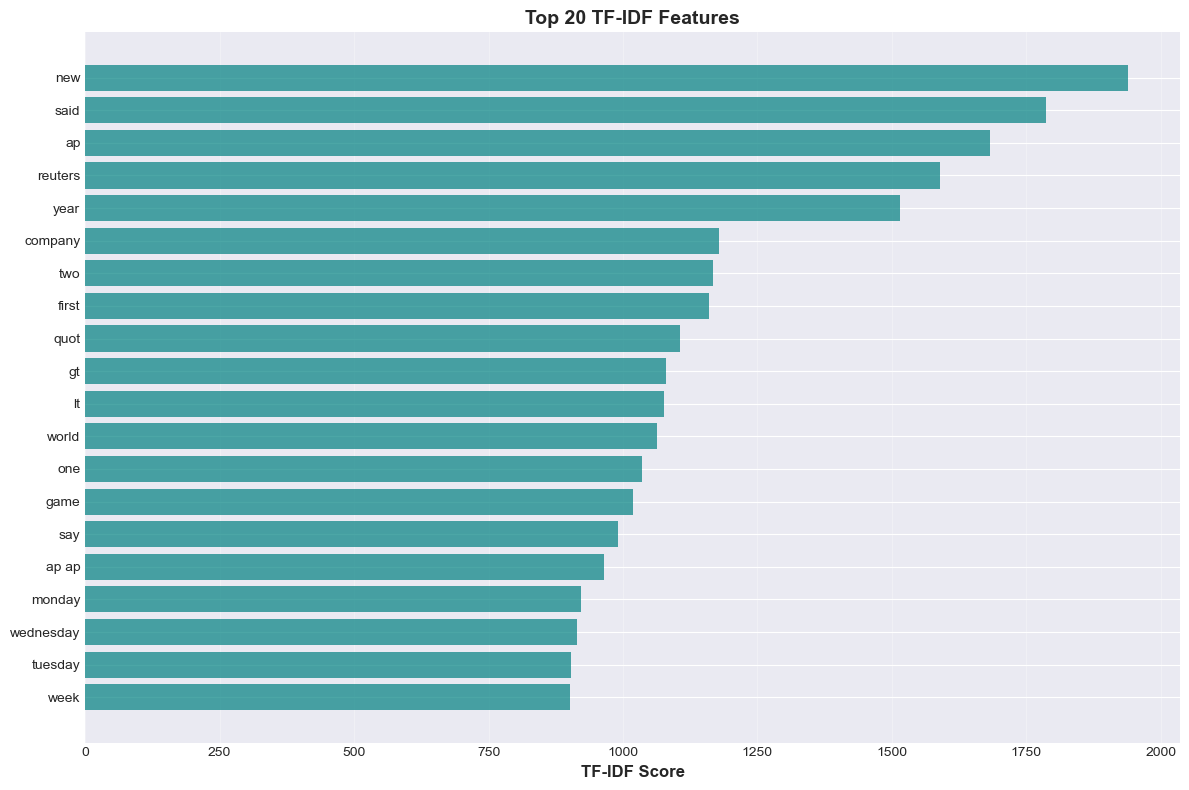

In [47]:
# Plot
fig, ax = plt.subplots(figsize=(12, 8))
features, scores = zip(*top_features)
y_pos = np.arange(len(features))

ax.barh(y_pos, scores, color='teal', alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(features)
ax.invert_yaxis()
ax.set_xlabel('TF-IDF Score', fontsize=12, fontweight='bold')
ax.set_title('Top 20 TF-IDF Features', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()